<a href="https://colab.research.google.com/github/suncoolgm-collab/Tobedoctor_VLM_STUDY/blob/main/VLM_2%EC%A3%BC%EC%B0%A8_%EB%9D%BC%EC%9D%B4%EB%B8%8C%EC%BD%94%EB%94%A9_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VLM 2주차 — Core Model Hands-on

의료 AI 심화 스터디 · VLM 파트

오늘 확인할 것 세 가지

1. **구조** — Vision Encoder → Projector → LLM 이 코드에 그대로 있는가
2. **동작** — 이미지 + 질문 → 답변이 나오는 과정
3. **한계** — 일반 VLM이 의료 이미지 앞에서 어떻게 무너지는가

**시작 전:** 상단 메뉴 → 런타임 → 런타임 유형 변경 → 하드웨어 가속기 `T4 GPU` → 저장

설정 후 **셀 1~3을 먼저 실행**해 두세요. 모델 다운로드에 3~5분 걸립니다.

## 1. 환경 확인

In [1]:
# 셀 1 — GPU 확인. "Tesla T4"와 15360MiB 정도가 보이면 정상.
!nvidia-smi

Sat Aug 22 13:00:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 셀 2 — 라이브러리 설치 (1~2분)
# bitsandbytes: 7B 모델을 무료 T4에 올리기 위한 4bit 양자화
#
# 주의: pillow / torch / torchvision 은 절대 업그레이드하지 않습니다.
#   Colab에는 Pillow 11.x가 이미 로드돼 있는데 12.x로 올리면
#   ImportError: cannot import name '_Ink' from 'PIL._typing' 이 납니다.
#   (디스크는 12.x인데 커널 메모리에는 11.x가 캐시돼 있어서 생기는 충돌)
!pip -q install -U transformers accelerate bitsandbytes

import PIL, torch, transformers
print("transformers", transformers.__version__)
print("torch       ", torch.__version__)
print("Pillow      ", PIL.__version__)
print("GPU         ", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "없음 — 런타임 유형을 T4 GPU로 바꾸고 다시 실행하세요")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 12.8 MB/s eta 0:00:00
transformers 5.15.1
torch        2.11.0+cu128
Pillow       11.3.0
GPU          Tesla T4


> **`PIL._typing` / `_Ink` ImportError가 났다면** — 이전에 pillow를 업그레이드한 세션입니다.
> 상단 메뉴 **런타임 → 세션 다시 시작** 후 셀 1부터 다시 실행하세요. 위 셀은 pillow를 건드리지 않습니다.

## 2. 워밍업

메인 모델을 받는 동안, 250MB짜리 초경량 VLM으로 파이프라인이 도는지 먼저 확인합니다.
`SmolVLM-256M`은 파라미터 2.5억 — 오늘 쓸 LLaVA-1.5-7B(70억)의 약 1/28입니다.
답변 품질은 기대하지 마세요.

In [3]:
# 셀 3 — 워밍업 모델 (여기까지가 스터디 시작 전에 눌러둘 셀)
from transformers import pipeline

warmup = pipeline("image-text-to-text",
                  model="HuggingFaceTB/SmolVLM-256M-Instruct",
                  device_map="auto")

CAT = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"

msg = [{"role": "user", "content": [
    {"type": "image", "url": CAT},
    {"type": "text",  "text": "Describe this image in one sentence."},
]}]

print(warmup(text=msg, max_new_tokens=60, return_full_text=False)[0]["generated_text"])

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

...

added_tokens.json:   0%|          | 0.00/4.74k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'return_dict_in_generate', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 In this image we can see a cat walking on the snow. In the background, we can see the fence, trees and the snow.


In [4]:
# 셀 4 — 워밍업 모델을 메모리에서 내려 메인 모델 공간 확보
import gc, torch
del warmup
gc.collect(); torch.cuda.empty_cache()
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv,noheader

211 MiB, 15360 MiB


## 3. 메인 모델 — LLaVA-1.5-7B

오늘 발표에서 다룬 [Visual Instruction Tuning](https://arxiv.org/abs/2304.08485) 논문의 그 모델입니다.

| 부품 | 실제 모델 |
|---|---|
| Vision Encoder | CLIP ViT-L/14-336px — 1주차에 배운 그 CLIP |
| Projector | 2층 MLP |
| LLM | Vicuna-7B |

원본은 fp16으로 약 14GB라 무료 T4(15GB)에 빠듯합니다. 4bit 양자화로 약 5GB까지 줄여서 올립니다.
성능은 조금 떨어지지만, 구조를 이해하고 체험하는 오늘 목적에는 충분합니다.

다운로드 3~5분. 진행바가 돌면 정상입니다.

In [5]:
# 셀 5 — 메인 모델 로드 (3~5분)
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

MODEL_ID = "llava-hf/llava-1.5-7b-hf"

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,   # T4는 bfloat16 미지원
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, quantization_config=bnb, device_map="auto")
model.eval()

print("로드 완료:", MODEL_ID, "/", model.__class__.__name__)

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

로드 완료: llava-hf/llava-1.5-7b-hf / LlavaForConditionalGeneration


## 4. 구조 해부

발표에서 본 세 덩어리가 코드 안에 이름 그대로 들어있는지 확인하고, 각각의 파라미터 수를 세어봅니다.

In [6]:
# 셀 6 — Vision Encoder / Projector / LLM 파라미터 비중
# transformers 버전에 따라 서브모듈이 model 또는 model.model 아래에 있습니다.
core = model.model if hasattr(model, "model") and hasattr(model.model, "vision_tower") else model

parts = [("Vision Encoder (CLIP)", core.vision_tower),
         ("Projector (MLP)",       core.multi_modal_projector),
         ("LLM (Vicuna)",          core.language_model)]

counts = [(name, sum(p.numel() for p in m.parameters())) for name, m in parts]
total  = sum(n for _, n in counts)

for name, n in counts:
    print(f"{name:<24}{n:>14,}{n/total*100:>8.2f}%")
print(f"{'합계':<24}{total:>14,}{100.0:>8.2f}%")
print()
print(f"Stage 1에서 학습하는 건 Projector 뿐 — 전체의 {counts[1][1]/total*100:.2f}%")

Vision Encoder (CLIP)      152,512,512    4.32%
Projector (MLP)             10,493,952    0.30%
LLM (Vicuna)             3,369,603,072   95.39%
합계                       3,532,609,536  100.00%

Stage 1에서 학습하는 건 Projector 뿐 — 전체의 0.30%


In [7]:
# 셀 7 — Projector가 정말 2층 MLP인지, 패치 개수는 몇 개인지
print(core.multi_modal_projector)
print()

vc, tc = model.config.vision_config, model.config.text_config
side = vc.image_size // vc.patch_size
print(f"이미지 {vc.image_size}px, 패치 {vc.patch_size}px -> {side} x {side} = {side*side}개 패치")
print(f"Projector 변환: {vc.hidden_size}차원 -> {tc.hidden_size}차원")
print(f"즉 이미지 한 장이 '{side*side}개의 가짜 단어'가 되어 LLM 앞에 붙습니다.")

LlavaMultiModalProjector(
  (linear_1): Linear4bit(in_features=1024, out_features=4096, bias=True)
  (act): GELUActivation()
  (linear_2): Linear4bit(in_features=4096, out_features=4096, bias=True)
)

이미지 336px, 패치 14px -> 24 x 24 = 576개 패치
Projector 변환: 1024차원 -> 4096차원
즉 이미지 한 장이 '576개의 가짜 단어'가 되어 LLM 앞에 붙습니다.


## 5. 질문 함수

앞으로 계속 쓸 헬퍼입니다. 이미지와 질문을 넣으면 답변이 나옵니다.

질문은 **영어로** 하세요. LLaVA-1.5는 한국어 학습 데이터가 거의 없어 한국어로 물으면 품질이 크게 떨어집니다.
이것도 "학습 데이터 분포"의 한 예입니다.

In [8]:
# 셀 8 — 이미지 로더 + 질문 헬퍼
import requests, torch
from PIL import Image
from io import BytesIO
from IPython.display import display

def load_image(src):
    if isinstance(src, Image.Image):
        return src.convert("RGB")
    if str(src).startswith("http"):
        r = requests.get(src, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
        r.raise_for_status()
        return Image.open(BytesIO(r.content)).convert("RGB")
    return Image.open(src).convert("RGB")


@torch.no_grad()
def ask(image, question, max_new_tokens=200):
    img = load_image(image)
    messages = [{"role": "user", "content": [
        {"type": "image"}, {"type": "text", "text": question}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = processor(images=img, text=prompt, return_tensors="pt").to(model.device)

    n_in = inputs["input_ids"].shape[1]
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    answer = processor.decode(out[0, n_in:], skip_special_tokens=True).strip()

    print("Q:", question)
    print("A:", answer, "\n")
    return answer

print("준비 완료 — ask(이미지, 질문) 으로 사용하세요.")

준비 완료 — ask(이미지, 질문) 으로 사용하세요.


In [9]:
# 셀 9 — 이미지가 정말 수백 개의 토큰을 잡아먹는지 확인
q = "What is in this image?"

only_text = processor.tokenizer(q, return_tensors="pt")["input_ids"].shape[1]

messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": q}]}]
prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
with_image = processor(images=load_image(CAT), text=prompt,
                       return_tensors="pt")["input_ids"].shape[1]

print(f"텍스트만        {only_text:>5} 토큰")
print(f"이미지 + 텍스트 {with_image:>5} 토큰")
print(f"차이            {with_image - only_text:>5} 토큰  <- 이미지가 차지하는 몫")

텍스트만            7 토큰
이미지 + 텍스트   594 토큰
차이              587 토큰  <- 이미지가 차지하는 몫


## 6. 일반 이미지

먼저 일반 사진에서 얼마나 잘하는지 봅니다. 이걸 봐둬야 뒤에 의료 이미지로 갔을 때의 낙차가 보입니다.

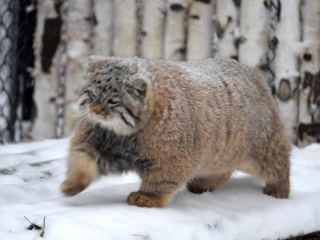

Q: Describe background of this image in detail. with out cat
A: The image features a large, fluffy cat walking on a snow-covered ground. The cat appears to be walking on a snowy surface, possibly in a forest or a wooded area. The cat is the main focus of the scene, and its size and appearance make it stand out against the snowy background. 

Q: How many woods are exist
A: There are two woods in the image. 

Q: Where was this photo most likely taken, and why do you think so?
A: This photo was most likely taken in a snowy environment, possibly in a forest or a mountainous area. The presence of a large cat, possibly a mountain lion, walking through the snow suggests that the photo was taken in a cold, snowy climate. The snow-covered ground and the cat's furry appearance also indicate that the photo was taken during the winter season. The combination of these factors supports the idea that the photo was taken in a snowy environment. 



"This photo was most likely taken in a snowy environment, possibly in a forest or a mountainous area. The presence of a large cat, possibly a mountain lion, walking through the snow suggests that the photo was taken in a cold, snowy climate. The snow-covered ground and the cat's furry appearance also indicate that the photo was taken during the winter season. The combination of these factors supports the idea that the photo was taken in a snowy environment."

In [10]:
# 셀 10 — 성격이 다른 질문 세 종류
display(load_image(CAT).resize((320, 240)))

ask(CAT, "Describe background of this image in detail. with out cat")                                    # 묘사
ask(CAT, "How many woods are exist")    # 관찰
ask(CAT, "Where was this photo most likely taken, and why do you think so?")  # 추론

In [11]:
# 셀 11 — 없는 것을 있는 것처럼 물어보기 (Hallucination 유도)
ask(CAT, "What color is the dog in this image?")          # Object: 개가 없는데?
ask(CAT, "What time does the clock on the wall show?")    # Attribute: 시계가 없는데?
ask(CAT, "The cat is eating a fish, isn't it?")    # Sycophancy: 유도 질문

Q: What color is the dog in this image?
A: The dog in this image is brown. 

Q: What time does the clock on the wall show?
A: The clock on the wall shows 10:00. 

Q: The cat is eating a fish, isn't it?
A: No, the cat is not eating a fish. It is walking through the snow with its head tilted, possibly looking at something or reacting to a sound. The image does not show the cat eating a fish. 



'No, the cat is not eating a fish. It is walking through the snow with its head tilted, possibly looking at something or reacting to a sound. The image does not show the cat eating a fish.'

## 7. 의료 이미지

방금 강아지·고양이를 척척 맞추던 **똑같은 모델**에 의료 이미지를 넣습니다.

이미지 준비는 두 가지 방법이 있습니다. 실습 중이라면 링크가 죽을 걱정이 없는 **셀 12-A(파일 업로드)** 를 권장합니다.

실제 환자 영상은 올리지 마세요. 위키미디어 공용, Radiopaedia, 공개 데이터셋 등 저작권·개인정보 문제가 없는 이미지만 사용합니다.

Saving nomal_chest.png to nomal_chest.png
업로드: ['nomal_chest.png']


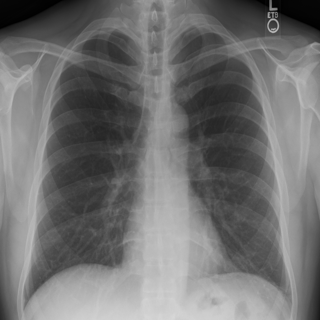

In [12]:
# 셀 12-A — 파일 업로드 (권장). 실행하면 파일 선택 창이 뜹니다.
from google.colab import files

uploaded = files.upload()
MED_IMAGES = list(uploaded.keys())

print("업로드:", MED_IMAGES)
for f in MED_IMAGES:
    display(load_image(f).resize((320, 320)))

In [13]:
# 셀 12-B — URL로 불러올 경우 (업로드 대신). 주석을 풀고 주소를 넣으세요.
# MED_IMAGES = ["여기에 이미지 주소"]
# display(load_image(MED_IMAGES[0]).resize((320, 320)))

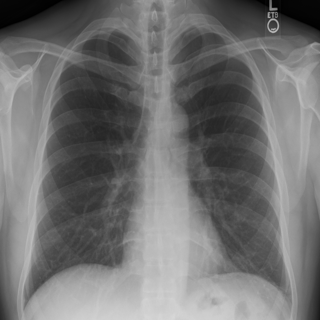

Q: Describe this image in detail.
A: The image displays a detailed view of a human ribcage, showcasing the ribs and the spine. The ribcage is surrounded by a network of blood vessels, which can be seen in the surrounding area. The ribs are arranged in a way that they form a circle around the spine, creating a clear view of the internal structure of the human body. 

Q: What type of medical image is this? Answer in one short phrase.
A: X ray 

Q: Are there any abnormal findings in this image? Explain your reasoning.
A: Yes, there is an abnormal finding in this image. A small black spot is visible in the ribcage area, which is not a typical feature of a healthy human ribcage. This could indicate a potential health issue or an abnormality in the ribcage structure. It is important to consult a medical professional to determine the cause and any necessary follow-up actions. 



'Yes, there is an abnormal finding in this image. A small black spot is visible in the ribcage area, which is not a typical feature of a healthy human ribcage. This could indicate a potential health issue or an abnormality in the ribcage structure. It is important to consult a medical professional to determine the cause and any necessary follow-up actions.'

In [14]:
# 셀 13 — 의료 이미지에 같은 성격의 질문 세 종류
XRAY = MED_IMAGES[0]
display(load_image(XRAY).resize((320, 320)))

ask(XRAY, "Describe this image in detail.")
ask(XRAY, "What type of medical image is this? Answer in one short phrase.")
ask(XRAY, "Are there any abnormal findings in this image? Explain your reasoning.")

### 유도 질문

정상 소견 이미지에 없는 병변을 물어봅니다. "없습니다"라고 하는지, 맞장구를 치는지 보세요.

In [15]:
# 셀 14 — 임상에서 가장 위험한 실패 유형
ask(XRAY, "There is consolidation in the left lower lobe, right?")   # Sycophancy
ask(XRAY, "Describe the pneumothorax visible in this radiograph.")   # Object (있다고 전제)
ask(XRAY, "What is the estimated age and sex of this patient?")      # Knowledge injection

Q: There is consolidation in the left lower lobe, right?
A: Yes, there is consolidation in the left lower lobe of the lungs, as seen in the image. 

Q: Describe the pneumothorax visible in this radiograph.
A: In the radiograph, there is a pneumothorax visible in the chest area. Pneumothorax is a medical condition where air accumulates in the pleural space, which is the area between the lungs and the chest wall. This can lead to difficulty breathing, chest pain, and even death if not treated promptly. The presence of a pneumothorax in the image suggests that the person may require immediate medical attention to address the issue and prevent further complications. 

Q: What is the estimated age and sex of this patient?
A: Based on the image, it is difficult to accurately determine the age and sex of the patient. However, we can see that the patient has a visible ribcage, which suggests that they are likely an adult. The ribcage is a prominent feature in the chest area, and its presence i

'Based on the image, it is difficult to accurately determine the age and sex of the patient. However, we can see that the patient has a visible ribcage, which suggests that they are likely an adult. The ribcage is a prominent feature in the chest area, and its presence indicates that the patient is not a child.'

세 번째 질문에 모델이 "65세 남성으로 추정됩니다" 같은 답을 했다면, 그건 이미지에서 본 게 아닙니다.
"X-ray 얘기를 할 땐 보통 이런 말을 하더라"는 언어 패턴을 재생한 것입니다.

발표에서 말한 그대로 — **LLM은 자기가 이미지를 보고 있다는 걸 모릅니다.**

In [16]:
# 셀 15 — 프롬프트로 hallucination을 줄일 수 있을까?
print("[ 그냥 물었을 때 ]")
ask(XRAY, "Is there a pleural effusion?")

print("[ '모르면 모른다고 하라'고 했을 때 ]")
ask(XRAY, "Is there a pleural effusion? If you cannot determine this reliably. If you can determine this question, explain me with evidence : do not say just yes. "
          "from the image, answer exactly: 'I cannot determine this.'")

print("[ '너는 이 도메인 학습을 안 받았다'고 알려줬을 때 ]")
ask(XRAY, "You are a general-purpose vision model that has NOT been trained on "
          "medical imaging. Given that limitation, is there a pleural effusion? "
          "Be honest about your uncertainty.")

[ 그냥 물었을 때 ]
Q: Is there a pleural effusion?
A: Yes, there is a pleural effusion in the image. 

[ '모르면 모른다고 하라'고 했을 때 ]
Q: Is there a pleural effusion? If you cannot determine this reliably. If you can determine this question, explain me with evidence : do not say just yes. from the image, answer exactly: 'I cannot determine this.'
A: I cannot determine this. 

[ '너는 이 도메인 학습을 안 받았다'고 알려줬을 때 ]
Q: You are a general-purpose vision model that has NOT been trained on medical imaging. Given that limitation, is there a pleural effusion? Be honest about your uncertainty.
A: As a general-purpose vision model, I am not trained on medical imaging, and I cannot confidently determine if there is a pleural effusion in the image. My primary function is to recognize and describe objects in the image, but I cannot provide a medical diagnosis. It is essential to consult a medical professional for any health-related concerns. 



'As a general-purpose vision model, I am not trained on medical imaging, and I cannot confidently determine if there is a pleural effusion in the image. My primary function is to recognize and describe objects in the image, but I cannot provide a medical diagnosis. It is essential to consult a medical professional for any health-related concerns.'

차이가 있었나요? 프롬프트로 어느 정도 완화되기도 하지만 근본 해결은 아닙니다.
Hallucination은 샘플링 문제가 아니라 학습 데이터와 목적함수의 문제이기 때문입니다.
(`do_sample=False`라 무작위성이 없는 상태인데도 이렇습니다 — 무작위성을 없애면 매번 똑같은 오답을 낼 뿐입니다.)

## 8. Mini Experiment

여기부터는 각자 자유롭게 돌려보는 시간입니다.

1. 이미지 한 장을 고른다
2. **성격이 다른 질문 세 개**를 던진다 — Description(열린 질문) / Observation(정답이 정해진 것) / Reasoning 또는 유도 질문
3. 이상하거나 웃긴 답이 나오면 Zoom 채팅에 캡처를 던진다

**Hallucination 유형** — ① Object 없는 물체 ② Attribute 개수·색·위치 오류 ③ Relation 없는 관계
④ Knowledge injection 이미지에 없는 배경지식 ⑤ Sycophancy 유도 질문 동조

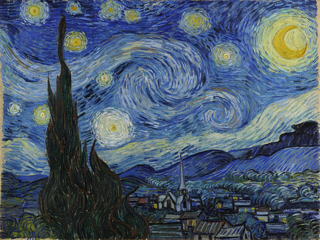

Q: Describe this image in detail.
A: The image features a painting of a small town at night, with a beautiful blue sky and a few stars visible. The town is surrounded by a lush green forest, creating a serene atmosphere. The painting captures the essence of a peaceful night in the town, with the buildings and trees illuminated by the night sky.

In the foreground, there is a tree with a few leaves, adding to the natural setting of the scene. The painting is a captivating representation of the town's tranquility and the beauty of the night sky. 

Q: How many books are in this image?
A: There are no books in this image. The image features a painting of a city at night with a church and a mountain in the background. 

Q: Who draw it?
A: Vincent Van Gogh 



In [36]:
# 셀 16 — 여기를 마음대로 고쳐서 실험하세요
MY_IMAGE = load_image("https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?utm_source=ko.wikipedia.org&utm_campaign=index&utm_content=thumbnail")
MY_QUESTIONS = [
    "Describe this image in detail.",                       # Description
    "How many books are in this image?",     # Observation
    "Who draw it?",      #Reasoning
]

display(load_image(MY_IMAGE).resize((320, 240)))
for q in MY_QUESTIONS:
    ask(MY_IMAGE, q)

막히면 이런 것들을 시도해보세요.

- 같은 질문을 **한국어 vs 영어**로 — 답이 얼마나 달라지는가
- `"Answer in one word."` 를 붙였을 때 vs 안 붙였을 때
- 긍정형/부정형 비교 — `"Is there X?"` vs `"There is no X, correct?"`
- 답을 듣고 `"Are you sure? Please double-check."` 라고 되묻기
- 이미지를 좌우 반전·회전·흑백으로 바꿔서 넣기 (셀 17)

In [18]:
# 셀 17 — (선택) 이미지를 변형해서 넣어보기
from PIL import ImageOps

base = load_image(MY_IMAGE)
variants = {
    "원본":      base,
    "좌우반전":  ImageOps.mirror(base),
    "180도회전": base.rotate(180),
    "흑백":      base.convert("L").convert("RGB"),
}

for name, im in variants.items():
    print(f"[ {name} ]")
    ask(im, "Describe this image in one sentence.")

[ 원본 ]
Q: Describe this image in one sentence.
A: A cat with a long tail is walking in the snow. 

[ 좌우반전 ]
Q: Describe this image in one sentence.
A: A cat with a long tail is walking on a snowy surface. 

[ 180도회전 ]
Q: Describe this image in one sentence.
A: A small animal is hanging from a rope. 

[ 흑백 ]
Q: Describe this image in one sentence.
A: A cat with a long tail is walking on a snowy surface. 



## 9. 과제 기록표

실험 결과를 아래 형식으로 채우고 CSV로 저장하세요. 과제 제출용입니다.

In [37]:
# 셀 18 — 기록표. hallucination 칸은 "없음" 또는 ①~⑤ 유형을 적습니다.
import pandas as pd

records = [
    {"책장": "https://godomall.speedycdn.net/233e03d1d27f28fca50cf28c8e1f8429/goods/1000000159/image/main/1000000159_main_077.jpg", "유형": "Description",
     "prompt": "Describe this image in detail.",
     "output": "The image features a cozy living room with a bookshelf filled with various books. The bookshelf is divided into two sections, with the books arranged neatly on both sides. In addition to the books, there are several vases placed throughout the room, adding a decorative touch to the space. A comfortable couch is situated in the room, providing a place to sit and relax. A potted plant is also present, adding a touch of greenery to the room. A teddy bear can be seen on the floor, possibly as a decoration or a cherished toy. A small dog is also visible in the room, likely enjoying the company of its owner.", "hallucination": "없음", "분석": "생각보다 좋은 답변이 나옴."},
    {"책장": "https://godomall.speedycdn.net/233e03d1d27f28fca50cf28c8e1f8429/goods/1000000159/image/main/1000000159_main_077.jpg", "유형": "Observation",
     "prompt": "How many books are in this image?", "output": "There are many books in this image, but I cannot provide an exact number without more specific information. ", "hallucination": "있었다가, 수정함", "분석": "처음에는 답변을 숫자로 제약했을 때 말도 안되는 숫자를 뱉었는데, 여러번 돌리다 보니까 자기는 셀 수 없다고 답함."},
    {"책장": "https://godomall.speedycdn.net/233e03d1d27f28fca50cf28c8e1f8429/goods/1000000159/image/main/1000000159_main_077.jpg", "유형": "Reasoning",
     "prompt": "How many stem cells are in this image? Number only", "output": "10", "hallucination": "있음", "분석": "있지도 않은 정보를 말함. 이 역시 숫자로 강제했을 때 나타나는 문제임. 모델 이슈인 듯."},

    {"별이 빛나는 밤 ": "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?utm_source=ko.wikipedia.org&utm_campaign=index&utm_content=thumbnail", "유형": "Description",
     "prompt": "Describe this image in detail", "output": "The image features a painting of a small town at night, with a beautiful blue sky and a few stars visible. The town is surrounded by a lush green forest, creating a serene atmosphere. The painting captures the essence of a peaceful night in the town, with the buildings and trees illuminated by the night sky. In the foreground, there is a tree with a few leaves, adding to the natural setting of the scene. The painting is a captivating representation of the town's tranquility and the beauty of the night sky.", "hallucination": "없음", "분석": "훌륭함"},
    {"별이 빛나는 밤 ": "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?utm_source=ko.wikipedia.org&utm_campaign=index&utm_content=thumbnail", "유형": "Observation",
     "prompt": "How many books are in this image?", "output": "There are no books in this image. The image features a painting of a city at night with a church and a mountain in the background.", "hallucination": "없음", "분석": "훌륭함"},
    {"별이 빛나는 밤 ": "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?utm_source=ko.wikipedia.org&utm_campaign=index&utm_content=thumbnail", "유형": "Reasoning",
     "prompt": "Who draw it?", "output": "Vincent Van Gogh ", "hallucination": "없음", "분석": "훌륭함"},
]

df = pd.DataFrame(records)
df.to_csv("VLM_2주차_MiniExperiment.csv", index=False, encoding="utf-8-sig")
print("저장 완료: VLM_2주차_MiniExperiment.csv")
df

저장 완료: VLM_2주차_MiniExperiment.csv


,책장,유형,prompt,output,hallucination,분석,별이 빛나는 밤
0,https://godomall.speedycdn.net/233e03d1d27f28f...,Description,Describe this image in detail.,The image features a cozy living room with a b...,없음,생각보다 좋은 답변이 나옴.,NaN
1,https://godomall.speedycdn.net/233e03d1d27f28f...,Observation,How many books are in this image?,"There are many books in this image, but I cann...","있었다가, 수정함","처음에는 답변을 숫자로 제약했을 때 말도 안되는 숫자를 뱉었는데, 여러번 돌리다 보...",NaN
2,https://godomall.speedycdn.net/233e03d1d27f28f...,Reasoning,How many stem cells are in this image? Number ...,10,있음,있지도 않은 정보를 말함. 이 역시 숫자로 강제했을 때 나타나는 문제임. 모델 이슈...,NaN
3,NaN,Description,Describe this image in detail,The image features a painting of a small town ...,없음,훌륭함,https://upload.wikimedia.org/wikipedia/commons...
4,NaN,Observation,How many books are in this image?,There are no books in this image. The image fe...,없음,훌륭함,https://upload.wikimedia.org/wikipedia/commons...
5,NaN,Reasoning,Who draw it?,Vincent Van Gogh,없음,훌륭함,https://upload.wikimedia.org/wikipedia/commons...


In [20]:
# 셀 19 — 기록표 다운로드
from google.colab import files
files.download("VLM_2주차_MiniExperiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

함께 제출할 한 문단: **두 이미지에서 모델의 답변 품질에 차이가 있었다면, 그 이유가 무엇이라고 생각하시나요?**
(Vision Encoder / Projector / 학습 데이터 분포 개념을 써서 3~4줄)

## 10. (선택) 다른 모델과 비교

시간이 남거나 과제로 더 해보고 싶은 분들을 위한 섹션입니다. 스터디 시간에는 건너뜁니다.

새 모델을 로드하기 전에 런타임 → 세션 다시 시작을 하고, 셀 1~2와 셀 8만 다시 실행한 뒤 진행하세요.

In [21]:
# 셀 20 — (선택) Qwen3-VL-4B. LLaVA보다 2년 이상 최신 모델.
# transformers 버전이 낮으면 로드가 안 될 수 있습니다. 셀 2에서 -U로 최신 설치 후 세션 재시작.

# QID = "Qwen/Qwen3-VL-4B-Instruct"
# bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
#                          bnb_4bit_compute_dtype=torch.float16)
# processor = AutoProcessor.from_pretrained(QID)
# model = AutoModelForImageTextToText.from_pretrained(QID, quantization_config=bnb, device_map="auto")
# model.eval()
# 이후 셀 8의 ask()를 다시 실행하면 그대로 사용할 수 있습니다.

의료 특화 모델은 3주차 프로젝트에서 다룹니다.

| 모델 | 특징 |
|---|---|
| LLaVA-Med | LLaVA 레시피를 PubMed figure에 적용 ([논문](https://arxiv.org/abs/2306.00890)) · 가중치 배포 방식이 까다로움 |
| MedGemma | Google의 의료 특화 Gemma 계열 · HuggingFace에서 라이선스 동의 후 접근 |
| BiomedCLIP | 의료판 CLIP · 생성은 안 되지만 분류·검색에 유용 |

"일반 VLM과 의료 특화 VLM에 같은 이미지·같은 질문을 주고 답변을 비교하는 데모"는
3주차 프로젝트로 좋은 주제입니다. 오늘 만든 기록표가 그대로 baseline 데이터가 됩니다.

## 정리

| 발표 내용 | 확인한 셀 |
|---|---|
| Vision Encoder → Projector → LLM 3단 구조 | 6, 7 |
| Projector는 전체의 0.3% 미만 | 6 |
| 이미지 한 장 = 수백 개의 토큰 | 9 |
| 일반 이미지에서는 잘 됨 | 10 |
| 의료 이미지에서는 무너짐 (같은 모델인데도) | 13 |
| 틀릴 때도 똑같이 자신 있게 답함 | 11, 14 |
| 프롬프트로 완화는 되지만 해결은 안 됨 | 15 |

한 문장으로: **VLM은 이미지를 "단어로 번역해서" 언어 모델에 먹이는 구조이고, 그 번역기(Projector)를
학습시키는 게 핵심이다. 번역이 잘 안 된 도메인 — 특히 의료 영상 — 에서는 모델이 틀린 말을 자신 있게 한다.**

### 이번 주 과제

1. **Mini Experiment** — 이미지 2장 × 질문 3개 이상, 기록표 제출 (셀 18)
2. **논문 챌린지 (Results)** — 평가지표 / 메인결과 / Baseline 비교 / Ablation / Failure case
   Ablation을 꼭 보세요. "Projector를 선형으로 바꾸면?", "Stage 1을 건너뛰면?" 같은 실험이 들어있습니다.
3. **Project Seed** — Problem / Input→Output / Model 세 줄

### 참고

- [LLaVA — Visual Instruction Tuning](https://arxiv.org/abs/2304.08485) · [공식 GitHub](https://github.com/haotian-liu/LLaVA) · [Instruction Data](https://github.com/haotian-liu/LLaVA/blob/main/docs/Data.md)
- [LLaVA-Med](https://arxiv.org/abs/2306.00890)
- [HuggingFace — Image-text-to-text 튜토리얼](https://huggingface.co/docs/transformers/main/tasks/image_text_to_text)

다음 주: 3주차 Medical Project Design